Now that we have done data exploration and some feature engineering, let's move onto making models to predict pickleball matches.  In the end, we should see some features that stand out and are important to learn what decides the outcome of pickleball matches.  First, let's install the required libraries and upload our dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import random
import os
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Load Data
df = pd.read_csv('matches_complete7.0.csv')

Next, let's pick the final features for the model. This code will fill any missing data with a zero. Then it will split the matches into a training set and a testing set. We will train thw model on the first 80 percent of the matches and test it on the final 20 percent.  Player styles might be important but it might not be.

In [ ]:
df['Target'] = (df['WinningTeam'] == 'TeamA').astype(int)

# Format the playstyle columns to have clean string names
playstyle_cols = [col for col in df.columns if 'Playstyle' in col]
for col in playstyle_cols:
    df[col] = 'Cluster_' + df[col].astype(str).str.replace('.0', '', regex=False)

# One-hot encode the playstyle clusters into separate binary columns
df_encoded = pd.get_dummies(df, columns=playstyle_cols, drop_first=False, dtype=int)

# Define the core numerical features
base_features = [
    'DUPR_Diff',
    'Weak_Link_Diff',
    'Consistency_Diff',
    'Net_Efficiency_Diff',
    'Drive_Diff',
    'TeamA_Driver_Net_Synergy',
    'TeamB_Driver_Net_Synergy',
    'TeamA_DUPR_Synergy',
    'TeamB_DUPR_Synergy'
]

# Append player styles as well
final_features = base_features + [col for col in df_encoded.columns if 'Playstyle' in col]

X = df_encoded[final_features].fillna(0)
y = df_encoded['Target']

# Split the dataset
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training on first {len(X_train)} matches.")
print(f"Testing on final {len(X_test)} matches.")
print(f"Total features used: {len(final_features)}")

Training on first 754 matches.
Testing on final 189 matches.
Total features used: 21


Now we will make a baseline model. Let's use a logistic regression model. Let's train this baseline model using only the DUPR difference between players.  Next, let's predict the outcomes for the test data.  The model returns a log loss of 0.6964 and an accuracy of 47.62 percent. This shows that the rating difference alone is a bad predictor.

In [ ]:
baseline = LogisticRegression()
baseline.fit(X_train[['DUPR_Diff']], y_train)

y_prob_base = baseline.predict_proba(X_test[['DUPR_Diff']])[:, 1]
y_pred_base = baseline.predict(X_test[['DUPR_Diff']])

base_log_loss = log_loss(y_test, y_prob_base)
base_acc = accuracy_score(y_test, y_pred_base)

print(f"Baseline Log Loss: {base_log_loss:.4f}")
print(f"Baseline Accuracy: {base_acc:.4f}")

Baseline Log Loss: 0.6964
Baseline Accuracy: 0.4762


Now let's use an XGBoost classifier with more parameters.  Let's test different settings to find the best version of this model using a grid search for trees, depth, subsample, minimum child weight, and learning rates. Then, we take the best model from that search. Let's predict the outcomes for the test data. Let's calculate the log loss and accuracy scores.  The model has a high accuracy of 84.13 percent. The low log loss shows it predicts the correct winner with high confidence.

In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.02, 0.03],
    'max_depth': [5, 6, 7],
    'subsample': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5]
}

grid = GridSearchCV(xgb, param_grid, scoring='neg_log_loss', cv=3)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

xgb_log_loss = log_loss(y_test, best_model.predict_proba(X_test)[:, 1])
xgb_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f"XGBoost Log Loss: {xgb_log_loss:.4f}")
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

XGBoost Log Loss: 0.3667
XGBoost Accuracy: 0.8148


This is a SHAP summary plot to explain the model. SHAP values use game theory to measure feature impact. The plot ranks the features from highest impact to lowest impact. The horizontal axis shows the size of the impact. Red dots indicate a high feature value. Blue dots indicate a low feature value.  For TeamA_DUPR_Synergy, high values increase the model output impact. Low values decrease it.  For Drive_Diff, high values push the prediction higher. Low values push it lower.  For TeamB_DUPR_Synergy, high values decrease the model output impact. Low values increase it.  The middle features in the SHAP summary plot show messy results. DUPR_Diff and Net_Efficiency_Diff have heavily overlapping dots. The model fails to use these features cleanly. Furthermore, the bottom features provide zero value. Weak_Link_Diff and TeamA_Driver_Net_Synergy sit on the zero line. They fail to move the prediction. Let's drop them from the code.  For columns like playstyle, we should keep them since the red and blue dots don't overlap much and they are at the bottom since they were one-hot encoded, meaning they have less meaning than other columns, but collectively they seem to be impactful.

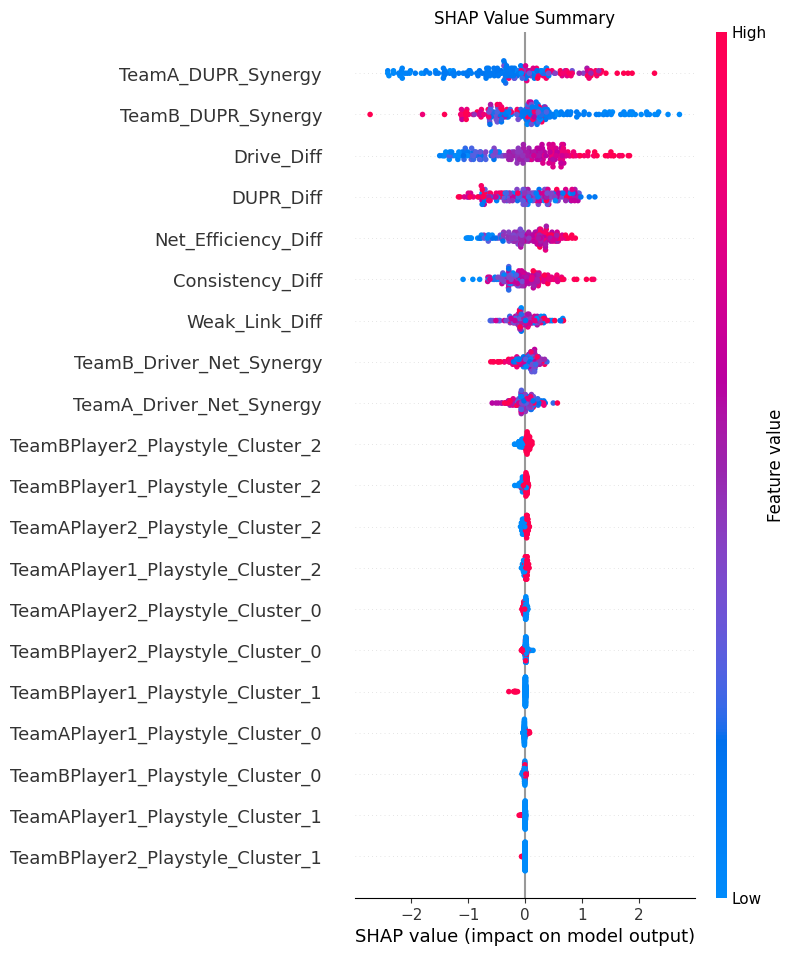

In [ ]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Value Summary')
plt.show()

Now with this new code, the model is leaner and became more accurate because of it.  

Best Hyperparameters: {'learning_rate': 0.03, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 400, 'subsample': 0.8}
Updated Model Accuracy: 0.8518518518518519


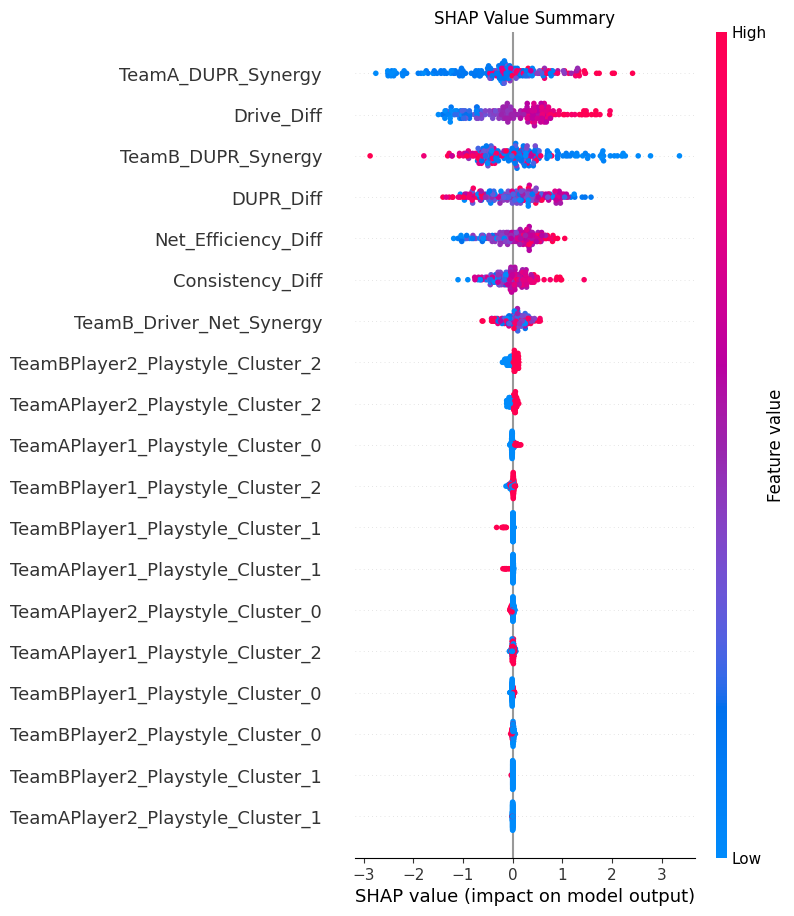

In [ ]:
# Remove features from the datasets
features_to_drop = ['Weak_Link_Diff', 'TeamA_Driver_Net_Synergy']
X_train_reduced = X_train.drop(columns=features_to_drop)
X_test_reduced = X_test.drop(columns=features_to_drop)

param_grid = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.02, 0.03],
    'max_depth': [5, 6, 7],
    'subsample': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5]
}

xgb_model = XGBClassifier(random_state=42)

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_reduced, y_train)

new_best_model = grid_search.best_estimator_

y_pred = new_best_model.predict(X_test_reduced)
final_accuracy = accuracy_score(y_test, y_pred)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Updated Model Accuracy: {final_accuracy}")

explainer = shap.TreeExplainer(new_best_model)
shap_values = explainer.shap_values(X_test_reduced)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_reduced, show=False)
plt.title('SHAP Value Summary')
plt.show()

 This is a Markov Chain which predicts the outcome of a pickleball point.  In these models, the probability of moving to the next state depends only on the current state.  The code has 6 different active states and two end states for a point.  

In [ ]:
def simulate_point_markov():
    transitions = {
        'Serve': {'Return': 0.90, 'Point_Server': 0.05, 'Point_Receiver': 0.05},
        'Return': {'Third_Shot_Drop': 0.60, 'Third_Shot_Drive': 0.20, 'Point_Server': 0.15, 'Point_Receiver': 0.05},
        'Third_Shot_Drop': {'Dinking': 0.70, 'Point_Server': 0.10, 'Point_Receiver': 0.20},
        'Third_Shot_Drive': {'Hand_Battle': 0.50, 'Point_Server': 0.20, 'Point_Receiver': 0.30},
        'Dinking': {'Dinking': 0.60, 'Hand_Battle': 0.20, 'Point_Server': 0.10, 'Point_Receiver': 0.10},
        'Hand_Battle': {'Hand_Battle': 0.30, 'Point_Server': 0.35, 'Point_Receiver': 0.35}
    }

    current_state = 'Serve'

    for _ in range(50):
        if current_state in ['Point_Server', 'Point_Receiver']:
            break

        probs = transitions[current_state]
        current_state = random.choices(list(probs.keys()), weights=list(probs.values()))[0]

    return current_state

# Run 4000 simulations
results = [simulate_point_markov() for _ in range(4000)]
server_win_pct = results.count('Point_Server') / 4000
print(f"Markov Simulation Server Win Rate: {server_win_pct:.1%}")

Markov Simulation Server Win Rate: 50.3%


Now our models are complete!  There is a lot more we can do with this dataset, but this is where we will stop.  Now we will save these models onto streamlit and present the data there!

In [ ]:
os.makedirs('models', exist_ok=True)

# Scale the reduced training data
scaler = StandardScaler()
X_train_reduced_scaled = scaler.fit_transform(X_train_reduced)

# Export the new model and scaler
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(new_best_model, 'models/xgb_model.pkl')

['models/xgb_model.pkl']